In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import *
from sklearn import linear_model as lm


In [2]:
#Read in data file (see data_processing.ipynb for how this file is generated)
codes_and_CIs = pd.read_csv('combined_COPUS_CI_data.csv')
#The target variable is the effect size
target = codes_and_CIs['Effect Size'].to_numpy()

ES_variance = codes_and_CIs['Effect Size Variance'].to_numpy()

In [3]:
def feature_selection(data, target, its=10000, prt = True, num_choose = 10, weights = False):
    if np.all(weights == False):
        weights = np.ones(data.shape[0])

    regr = WLS(target, data, weights=weights).fit()
    true_base_BIC = regr.bic
    BICs = np.zeros(its)
    keepers = np.zeros((its, data.shape[1]), dtype=bool)
    keepers[:, -1] = 1  #always keep the bias term

    for j in range(its):
        base_BIC = true_base_BIC * 1
        
        #randomly shuffle order of variables, skipp bias
        shuffle = np.append(np.array([data.shape[1] - 1]), np.random.permutation(data.shape[1] - 1))
        pruned_data = data[:, shuffle]

        i = 1
        keeping = []
        while i < pruned_data.shape[1]:

            #remove one feature
            cut_data = np.delete(pruned_data, i, axis=1)

            regr = WLS(target, cut_data, weights=weights).fit()
            new_BIC = regr.bic

            #if BIC doesn't increase by more than 2, remove the variable and update the base BIC
            ################################################3
            if new_BIC   < base_BIC  : #changed tolerance to 2
            #####################################################3
                pruned_data = np.delete(pruned_data, i, axis=1)
                base_BIC = new_BIC
            #otherwise keep the variable and move to the next one
            else:
                keepers[j, shuffle[i + (data.shape[1] - pruned_data.shape[1])]] = 1
                keeping.append(i + (data.shape[1] - pruned_data.shape[1]))
                i += 1
            
        BICs[j] = base_BIC

        if not j % 1000 and prt:
            print(f'Iteration {j + 1} finished with BIC {base_BIC.round(2)}')
    good_fits = np.argsort(BICs)[:num_choose]
    return keepers, BICs, good_fits

In [4]:
#feature selection and aic functions are called in from functions.py

#pick number of bootstrap samples and number of best fits to use for LOO predictions
bootstrap_n = 10
n_fits = 10
#pick number of feature selection order randomizations to use for each LOO fit
def feature_boot_LOO(data, target, ES_variance, bootstrap_n = 10, n_fits = 10, ):
#create empty arrays to store weights and predictions for each bootstrap sample, each best fit, and each data point
    feature_selection_its = int(data.shape[0]*5)
    LOO_predictions = np.zeros(( n_fits, bootstrap_n, data.shape[0]))
    LOO_weights = np.zeros(( n_fits, bootstrap_n, data.shape[0], data.shape[1]))
    good_fit_BICs = np.zeros(( n_fits, data.shape[0] ))

    #perform leave-one-out cross-validation for each of the best fits
    for k in range(data.shape[0]): 
        if not k % 10:
            print(f'LOO iteration {k} of {data.shape[0]}')
        cut_data = np.delete(data, k, axis=0)
        cut_truth = np.delete(target, k, axis=0)
        cut_weights = np.delete(1/ES_variance, k, axis=0)
        keepers, BICs, good_fits = feature_selection(cut_data, cut_truth, its=feature_selection_its, prt = False, num_choose = n_fits, weights = cut_weights)
        #print(BICs[good_fits])

        good_fit_BICs[:, k] = BICs[good_fits]
        LOO_predictions[:, :, k], LOO_weights[:, :, k, :] = bootstrap_LOO(data, target, keepers, good_fits, 
                                                                        bootstrap_n=bootstrap_n, leave_out = k, weights = 1/ES_variance   )
    return LOO_predictions, LOO_weights, good_fit_BICs

In [5]:
    ##plotting LOO predictions with error bars representing uncertainty across different fits
def LOO_plot(target, LOO_predictions_mean, LOO_predictions_std, threshhold = .3, measurement_uncertainty = 1):
    

    x, y = target, LOO_predictions_mean
    plt.plot([np.min(x), np.max(x)], [np.min(x), np.max(x)], 'k--', alpha=.5)

    where_low_error = np.where( (y > np.min(x) - threshhold) & (y < np.max(x) + threshhold))
    where_high_error = np.where((y < np.min(x) - threshhold) | (y > np.max(x) + threshhold))
    low_x, low_y = x[where_low_error], y[where_low_error]
    high_x, high_y = x[where_high_error], y[where_high_error]

    m, b = np.polyfit(x, y, 1)
    xi = np.linspace(np.min(x), np.max(x), 100)



    plt.scatter(low_x, low_y, label=f'Prediction uncertainty < {threshhold}', color='blue', alpha=0.7)
    plt.errorbar(low_x, low_y, yerr=LOO_predictions_std[where_low_error], fmt='o', color='blue', alpha=0.3)

    plt.scatter(high_x, high_y, label=f'Prediction uncertainty > {threshhold}', color='red', alpha=0.7)
    plt.errorbar(high_x, high_y, yerr=LOO_predictions_std[where_high_error], fmt='o', color='red', alpha=0.3)

    if type(measurement_uncertainty) != int:
        plt.errorbar(high_x, high_y, xerr = measurement_uncertainty[where_high_error], fmt='o', color='red', alpha=0.3)
        plt.errorbar(low_x, low_y, xerr = measurement_uncertainty[where_low_error], fmt='o', color='blue', alpha=0.3)
    else:
        measurement_uncertainty = np.ones(data.shape[0])/data.shape[0]


    plt.xlabel(f'Measured Effect Size')
    plt.ylabel(f'Predicted Effect Size')
    plt.ylim(-.5, 3.5)
    #plt.title(f'Leave-One-Out Predictions vs Target')
    #plt.legend()
    plt.savefig('Figs/LOO.png', dpi=300)
    plt.show()

    weights = 1 / measurement_uncertainty
    weights = weights 

    print(f'R^2: {np.corrcoef(x, y)[0, 1]**2:.3f}')
    print(f'Mean absolute error: {np.mean(np.abs(y-x)):.4f}')
    print(f'Weighted MAE: {np.mean(np.abs(y-x) * weights):.4f}')
    print('-----')
    print(f'R^2 removing predictions outside measured range: {np.corrcoef(low_x, low_y)[0, 1]**2:.3f}')
    print(f'MAE removing predictions outside measured range: {np.mean(np.abs(low_y-low_x)):.4f}')
    print(f'Weighted MAE removing predictions outside measured range: {np.mean(np.abs(low_y-low_x) * weights[where_low_error]):.4f}')



In [6]:
def weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1):
    weights = np.zeros(good_fit_BICs.shape)
    for i in range(data.shape[0]):
        weights[:, i] = BIC_weights(good_fit_BICs[:, i])
    print(f'Minimum BIC: {np.min(good_fit_BICs):.2f}')
    weighted_predictions = np.sum(weights.reshape(-1, 1, data.shape[0]) * LOO_predictions, axis = 1)
    LOO_means = np.mean(weighted_predictions, axis=0)
    #LOO_means = np.mean(LOO_predictions, axis = (0,1  ))

    LOO_stds = np.sum(weights * np.std(LOO_predictions, axis=(1)), axis = 0)
    #LOO_stds = np.std(LOO_predictions, axis=(0, 1))
    LOO_plot(target, LOO_means, LOO_stds, measurement_uncertainty = np.sqrt(ES_variance), threshhold = threshhold)

In [7]:
def BIC_weights(BICs):
    exp_BICs = np.exp(-0.5 * (BICs - np.min(BICs)))
    return exp_BICs / np.sum(exp_BICs)

### Maximum codes: Lec, CG, WG, OG, SQ

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: -35.12


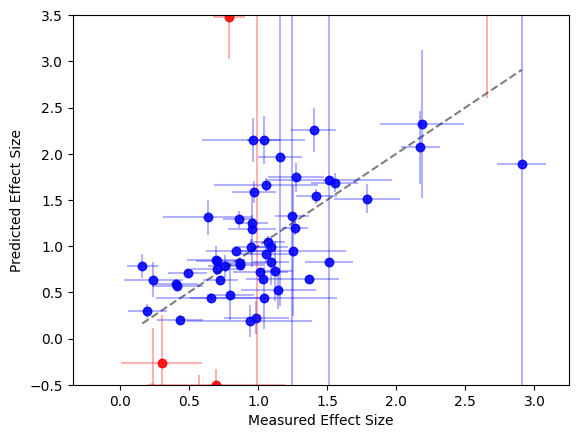

R^2: 0.007
Mean absolute error: 1.0514
Weighted MAE: 5.3342
-----
R^2 removing predictions outside measured range: 0.388
MAE removing predictions outside measured range: 0.3576
Weighted MAE removing predictions outside measured range: 1.9073


In [9]:
#Maximum number of codes, choose CG over CQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Same but choose CQ over CG

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 42.45


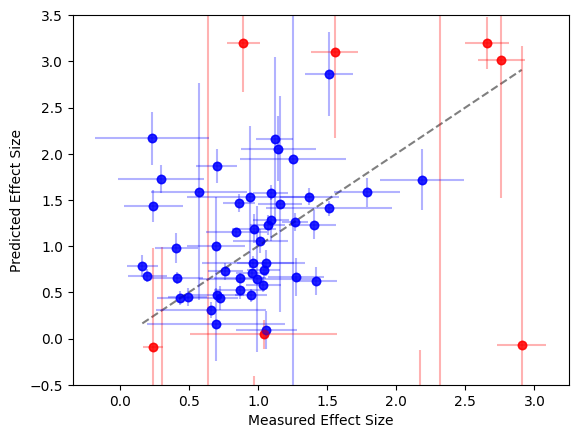

R^2: 0.012
Mean absolute error: 1.7281
Weighted MAE: 8.8555
-----
R^2 removing predictions outside measured range: 0.085
MAE removing predictions outside measured range: 0.4918
Weighted MAE removing predictions outside measured range: 2.5302


In [ ]:
#Maximum number of codes, choose CQ over CG
#CG does way better


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CQ', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Replace WG and OG with PQ

PQ necessarily happens alongside WG and OG

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 107.38


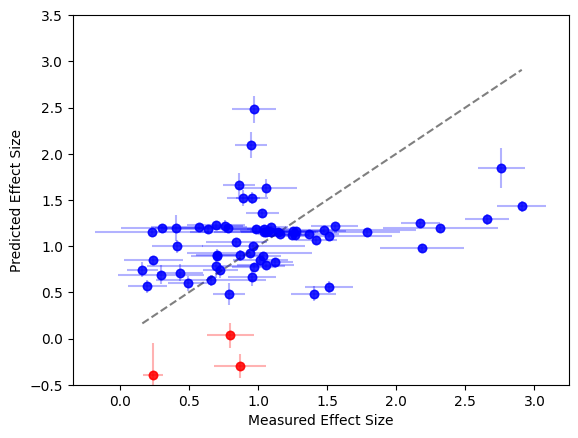

R^2: 0.074
Mean absolute error: 0.4890
Weighted MAE: 2.7033
-----
R^2 removing predictions outside measured range: 0.089
MAE removing predictions outside measured range: 0.4395
Weighted MAE removing predictions outside measured range: 2.4736


In [ ]:
#replace OG and WG with PQ
#does way worse

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'PQ', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Remove Lec: CG, WG, OG,  SQ (only student vars)

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 57.50


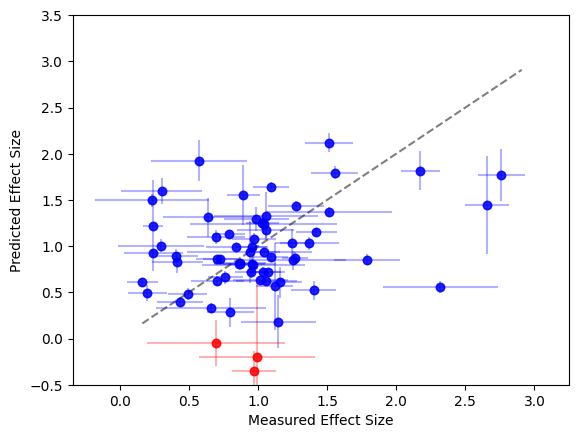

R^2: 0.203
Mean absolute error: 0.6189
Weighted MAE: 2.9976
-----
R^2 removing predictions outside measured range: 0.084
MAE removing predictions outside measured range: 0.4322
Weighted MAE removing predictions outside measured range: 2.3502


In [ ]:
#remove lec

#these will be input features for the model
data = codes_and_CIs[[ 'WG', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features


data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)


## Remove OG: Lec, CG, WG, SQ 

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 35.50


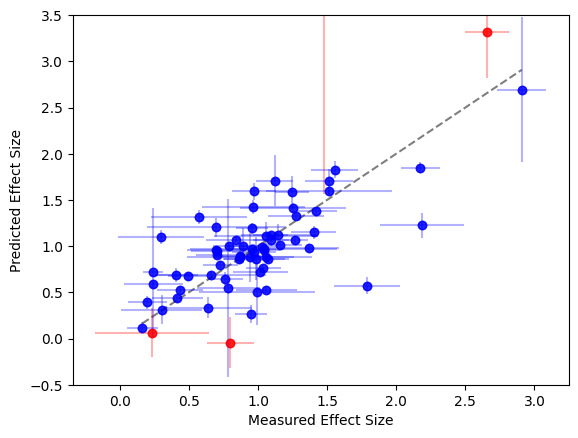

R^2: 0.252
Mean absolute error: 0.3691
Weighted MAE: 1.7005
-----
R^2 removing predictions outside measured range: 0.508
MAE removing predictions outside measured range: 0.2493
Weighted MAE removing predictions outside measured range: 1.3640


In [ ]:


#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Remove WG: Lec, CG, OG, SQ

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 106.67


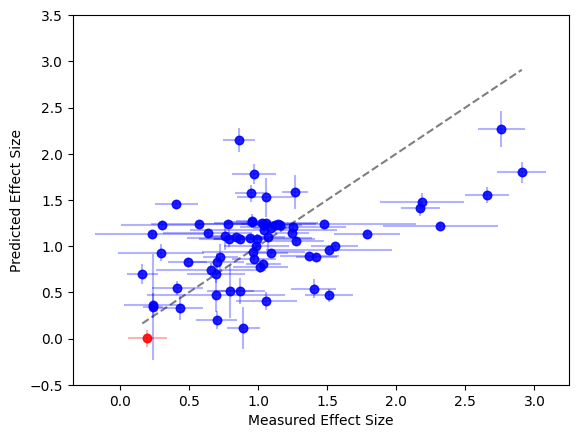

R^2: 0.254
Mean absolute error: 0.4019
Weighted MAE: 2.2582
-----
R^2 removing predictions outside measured range: 0.231
MAE removing predictions outside measured range: 0.4050
Weighted MAE removing predictions outside measured range: 2.2705


In [ ]:
#remove WG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Remove SQ: Lec, CG, WG, OG

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 69.89


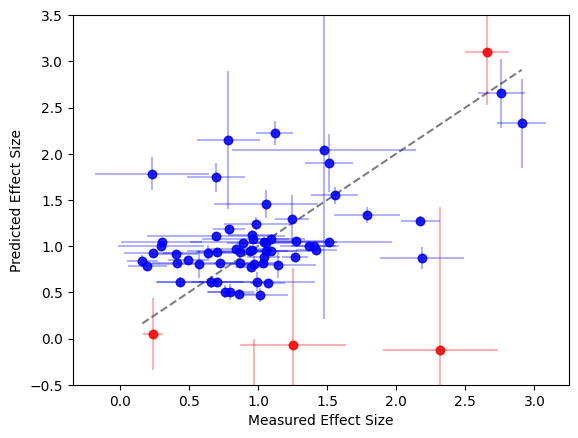

R^2: 0.042
Mean absolute error: 0.6183
Weighted MAE: 3.5773
-----
R^2 removing predictions outside measured range: 0.250
MAE removing predictions outside measured range: 0.3766
Weighted MAE removing predictions outside measured range: 1.9637


In [ ]:
#remove SQ

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG',  ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Combine WG and OG

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 91.95


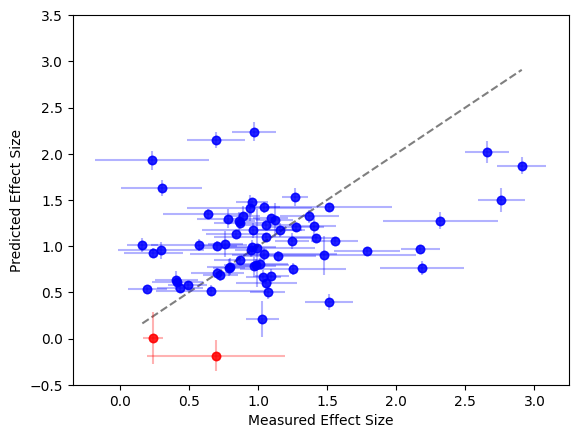

R^2: 0.092
Mean absolute error: 0.4510
Weighted MAE: 2.3613
-----
R^2 removing predictions outside measured range: 0.068
MAE removing predictions outside measured range: 0.4477
Weighted MAE removing predictions outside measured range: 2.3559


In [ ]:
#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 85.37


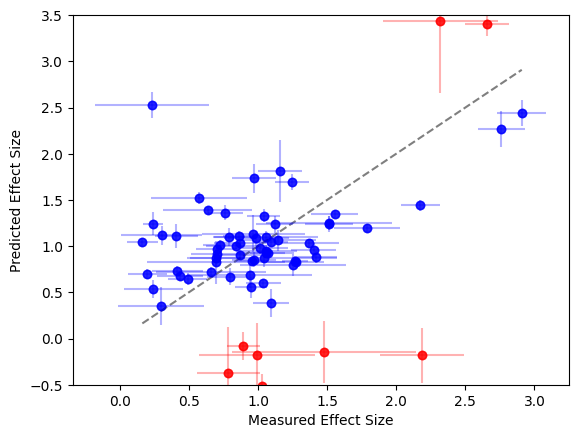

R^2: 0.169
Mean absolute error: 0.5095
Weighted MAE: 2.7767
-----
R^2 removing predictions outside measured range: 0.203
MAE removing predictions outside measured range: 0.3789
Weighted MAE removing predictions outside measured range: 2.2562


In [ ]:
#combine CG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 1] = data[:, 1] + data[:, 3]
data = data[:, [0, 1, 2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

## Combine all group work

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 104.90


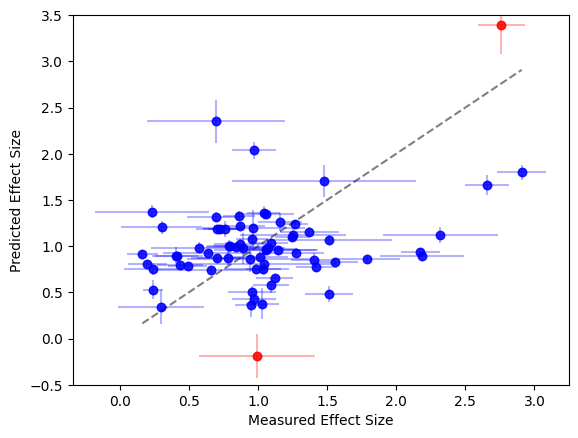

R^2: 0.144
Mean absolute error: 0.4641
Weighted MAE: 2.4851
-----
R^2 removing predictions outside measured range: 0.054
MAE removing predictions outside measured range: 0.4509
Weighted MAE removing predictions outside measured range: 2.4625


In [ ]:
#combine all group work

#combine WG and OG

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'OG', 'SQ' ]].to_numpy()
data[:, 2] = data[:, 2] + data[:, 3] + data[:, 1]
data = data[:, [0,  2, 4]] #remove OG
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

# Model Complexity

In [ ]:
#up to third order terms

def add_cross_terms_3(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))


    data = np.hstack((data, cross_factors))

    

    data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order ter

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 38.36


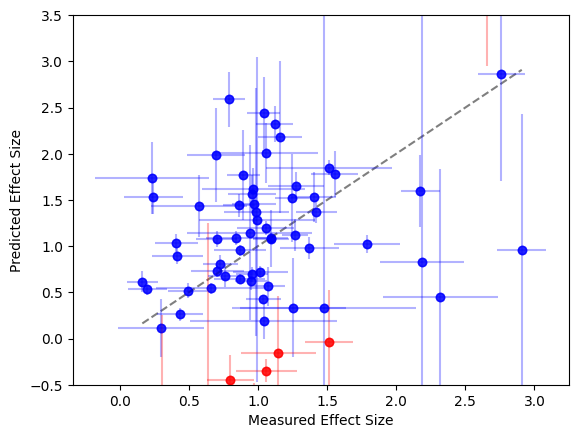

R^2: 0.013
Mean absolute error: 1.1383
Weighted MAE: 6.6990
-----
R^2 removing predictions outside measured range: 0.045
MAE removing predictions outside measured range: 0.5708
Weighted MAE removing predictions outside measured range: 2.9801


In [ ]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',  'OG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 56.97


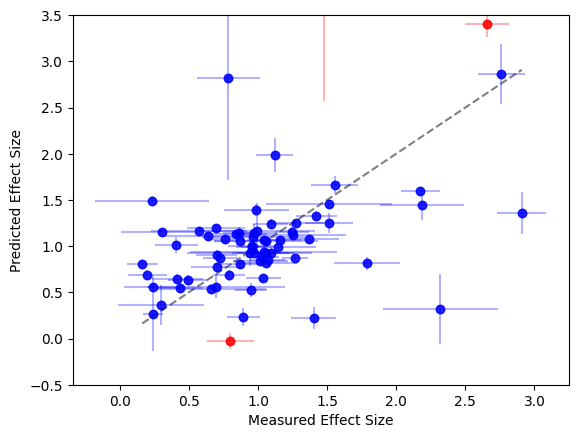

R^2: 0.222
Mean absolute error: 0.4009
Weighted MAE: 2.0016
-----
R^2 removing predictions outside measured range: 0.160
MAE removing predictions outside measured range: 0.3598
Weighted MAE removing predictions outside measured range: 1.8951


In [ ]:
#up to thrid order
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_3(data)

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

In [ ]:
#up to second order terms

def add_cross_terms_2(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))


    data = np.hstack((data, cross_factors))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 70.68


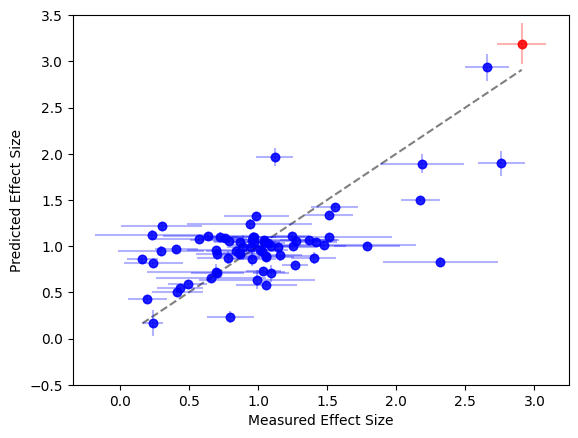

R^2: 0.492
Mean absolute error: 0.3081
Weighted MAE: 1.5982
-----
R^2 removing predictions outside measured range: 0.400
MAE removing predictions outside measured range: 0.3084
Weighted MAE removing predictions outside measured range: 1.5981


In [ ]:
#add in PQ, up to second
# #these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG',   'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_2(data)
LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)

In [ ]:
#no 1st order terms, get rid of colinearity
def add_cross_terms_no1(data):
    ## this functions adds polynomial and cross terms to the data
        
    pts, features = data.shape
    #
    cross_factors = (data[:, :features].reshape(pts, 1, features) *data[:, :features].reshape(pts, features, 1))#.reshape(pts, features * features)
    #keep only upper triangle

    #second order terms
    cross_factors = cross_factors[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]
    cross_factors = np.hstack((cross_factors, data**2))

    #third order terms
    cross_21 = (data.reshape(pts, 1, features)**2 * data.reshape(pts, features, 1))
    cross_12 = (data.reshape(pts, 1, features) * data.reshape(pts, features, 1)**2)


    cross_factors = np.hstack((cross_factors, cross_21[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))
    cross_factors = np.hstack((cross_factors, cross_12[:, np.triu_indices(features, k=1)[0], np.triu_indices(features, k=1)[1]]))

    data = np.hstack((cross_factors, data[:, :1]*data[:, 1:2]* data[:, 2:3]))  # interaction term for first three features
    if features >= 4:
        data = np.hstack((data, data[:, :1]*data[:, 1:2]* data[:, 3:4]))  # interaction term for first second and fourth features
        data = np.hstack((data, data[:, :1]*data[:, 2:3]* data[:, 3:4]))  # interaction term for first third and fourth features
        data = np.hstack((data, data[:, 1:2] * data[:, 2:3] * data[:, 3:4]))  # interaction term for second third and fourth features
    
    #######################
    if features >= 5:
        data = np.hstack((data, data[:, :1] * data[:, 1:2] * data[:, 4:5]))  # interaction term for first second and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 2:3] * data[:, 4:5]))  # interaction term for first third and fifth features
        data = np.hstack((data, data[:, :1] * data[:, 3:4] * data[:, 4:5]))  # interaction term for first fourth and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:,  2:3] * data[:, 4:5]))  # interaction term for second third and fifth features
        data = np.hstack((data, data[:, 1:2] * data[:, 3:4] * data[:, 4:5]))  # interaction term for second fourth and fifth features
        data = np.hstack((data, data[:, 2:3] * data[:, 3:4] * data[:, 4:5]))  # interaction term for third fourth and fifth features
        ########################
    data = np.hstack((data, data[:, :4]**3))  #third order terms

    
    #fourth order terms
    data = np.hstack((data, data[:, :4]**4))

    data = np.hstack((data, np.ones((data.shape[0], 1))))  # add bias term
    return data


LOO iteration 0 of 69
LOO iteration 10 of 69
LOO iteration 20 of 69
LOO iteration 30 of 69
LOO iteration 40 of 69
LOO iteration 50 of 69
LOO iteration 60 of 69
Minimum BIC: 65.24


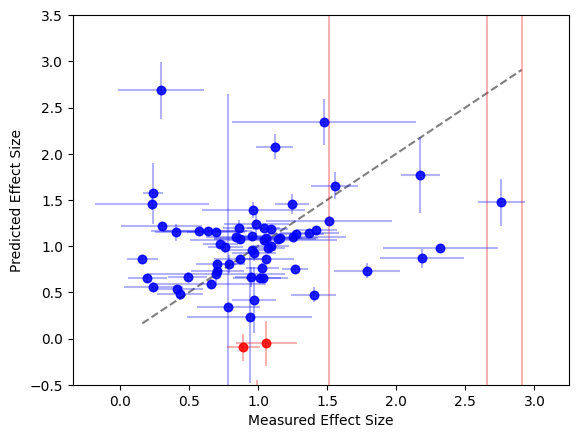

R^2: 0.285
Mean absolute error: 0.8680
Weighted MAE: 4.8157
-----
R^2 removing predictions outside measured range: 0.028
MAE removing predictions outside measured range: 0.4230
Weighted MAE removing predictions outside measured range: 2.2711


In [ ]:
#no first order

#these will be input features for the model
data = codes_and_CIs[[ 'Lec', 'CG', 'WG', 'SQ', ]].to_numpy()
#This is a linear regression model, but we use nonlinear terms by adding polynomila features
data = add_cross_terms_no1(data)

LOO_predictions, LOO_weights, good_fit_BICs = feature_boot_LOO(data, target, ES_variance,  )

weighted_LOO_predictions(LOO_predictions, good_fit_BICs, threshhold = .1)